Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f1b381eb7e0>
  [1] SingleMuonAnalysis -> Analysis builder=<function run_analysis at 0x7f1b381ebba0>
  [2] PlottingMuonAnalysis -> Plotting builder=<function plot_results at 0x7f1b381ebc40>
Edges:
  Fileset -> SingleMuonAnalysis
  SingleMuonAnalysis -> PlottingMuonAnalysis
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f1b381eb7e0>
  -> materialized at cache_hist/Fileset/308ad2089fe7984aed2aa4ecc8b94f514c652884af87b3acccf3ba7eec3fb944
Executing step 'SingleMuonAnalysis' of type 'Analysis' with the user code <function run_analysis at 0x7f1b381ebba0>
------------------------------------
Processing fileset_chunk_0.json
conn: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': '5ef9d7cc8a0e480b8f98378eed998d87', 'token': 'test'}
Reconnected to histserv: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': '5ef9d7cc8a0e480b8f98378eed

Output()

/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py:1171: UserWarning: Performed attempt 1 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1185, in automatic_retries
    raise e
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1169, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/cms-jovyan/coffea/coffea/src/coffea/processor/executor.py", line 1239, in metadata_fetcher_root
    with uproot.open({item.filename: None}, timeout=xrootdtimeout) as file:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packa

Failure caught!
------------------------------------
Processing fileset_chunk_1.json
conn: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': '5ef9d7cc8a0e480b8f98378eed998d87', 'token': 'test'}
Reconnected to histserv: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': '5ef9d7cc8a0e480b8f98378eed998d87', 'token': 'test'}


...

Output()

Successfully processed!
------------------------------------
Processing fileset_chunk_4.json
conn: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': '5ef9d7cc8a0e480b8f98378eed998d87', 'token': 'test'}
Reconnected to histserv: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': '5ef9d7cc8a0e480b8f98378eed998d87', 'token': 'test'}


Output()

Output()

Successfully processed!
  -> materialized at cache_hist/Analysis/ba9d6622a93c8ff44af9d47263e2d51724186dcfb7532204872c1a874b04eb93
Executing step 'PlottingMuonAnalysis' of type 'Plotting' with the user code <function plot_results at 0x7f1b381ebc40>


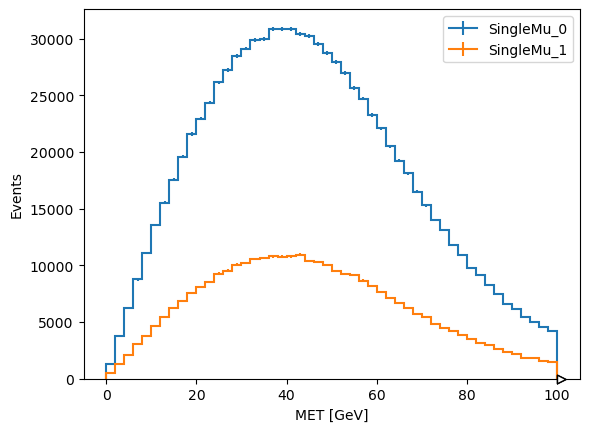

  -> materialized at cache_hist/Plotting/4fc626a74e22d4eae15ce535de495d2f191b28272fee9a50f0ec85eb617bae79

=== Run Summary ===
  ✓  Fileset                        Fileset
  !  SingleMuonAnalysis             Analysis             4/5 chunks OK
       FAILED fileset_chunk_0.json: Err(OSError('Failed to submit <bound method File.open of <XRootD.client.file.File object at 0x7f70f0b8c320>> request: [FATAL] Invalid address'))
  ✓  PlottingMuonAnalysis           Plotting



In [1]:
import histserv
from workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, render
from analysis_hist import get_fileset, run_analysis, plot_results, hist_template

# hist_client = histserv.Client(address="[::]:50051") # local
hist_client = histserv.Client(address="histserv.cmsaf-dev.flatiron.hollandhpc.org:8788") # coffea-casa
histserv_connection_info = hist_client.init(hist=hist_template(), token="test").get_connection_info()
# print(histserv_connection_info)


step_fileset = Step(
                    name="Fileset",
                    step_type=Fileset,
                    builder=get_fileset,
                )

step_analysis = Step(
                        name="SingleMuonAnalysis",
                        step_type=Analysis,
                        builder=run_analysis,
                    )

step_plotting = Step(
                    name="PlottingMuonAnalysis",
                    step_type=Plotting,
                    builder=plot_results,
                )

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

# To reconnect to an existing histogram on a subsequent run, read
# connection_info from the previous result and pass it here:
#   conn = result["results"]["SingleMuonAnalysis"]["merged"]
#   config = RunConfig(hist_client=hist_client, histserv_connection_info=conn, ...)

config = RunConfig(
                   hist_client=hist_client, 
                   histserv_connection_info=histserv_connection_info, 
                   percentage=20, 
                   cache_dir="cache_hist"
                  )

result = render(workflow, config)

In [2]:
conn = result["results"]["SingleMuonAnalysis"]["merged"]
print(conn)

{'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': '5ef9d7cc8a0e480b8f98378eed998d87', 'token': 'test'}
